## **1. PREPROCESSING RAW DATA**

In [1]:
# Upload dataset
from google.colab import files
files.upload()

Saving customer_shopping_data.csv to customer_shopping_data.csv


{'customer_shopping_data.csv': b'invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall\r\nI138884,C241288,Female,28,Clothing,5,1500.4,Credit Card,5/8/2022,Kanyon\r\nI317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul\r\nI127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity\r\nI173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM\r\nI337046,C189076,Female,53,Books,4,60.6,Cash,24/10/2021,Kanyon\r\nI227836,C657758,Female,28,Clothing,5,1500.4,Credit Card,24/05/2022,Forum Istanbul\r\nI121056,C151197,Female,49,Cosmetics,1,40.66,Cash,13/03/2022,Istinye Park\r\nI293112,C176086,Female,32,Clothing,2,600.16,Credit Card,13/01/2021,Mall of Istanbul\r\nI293455,C159642,Male,69,Clothing,3,900.24,Credit Card,4/11/2021,Metrocity\r\nI326945,C283361,Female,60,Clothing,2,600.16,Credit Card,22/08/2021,Kanyon\r\nI306368,C240286,Female,36,Food & Beverage,2,10.46,Cash,25/12/2022,Metrocity\r\nI139207,C191

In [23]:
# Membaca dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("customer_shopping_data.csv")

In [3]:
# Cek Missing Value
df.isnull().sum()

,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


In [4]:
# Cek Duplikat
df.duplicated().sum()

np.int64(0)

In [5]:
# Cek Tipe Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [6]:
# Ubah tipe data kolom invoice_date
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)

In [7]:
# Cek
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  object        
 1   customer_id     99457 non-null  object        
 2   gender          99457 non-null  object        
 3   age             99457 non-null  int64         
 4   category        99457 non-null  object        
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   payment_method  99457 non-null  object        
 8   invoice_date    99457 non-null  datetime64[ns]
 9   shopping_mall   99457 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 7.6+ MB


In [8]:
# Membuat kolom total_sales
df['total_sales'] = df['quantity'] * df['price']

In [9]:
# Menampilkan 5 baris pertama
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,total_sales
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,7502.00
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,5401.53
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,300.08
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM,15004.25
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,242.40


In [10]:
# Simpan dataset setelah pembersihan
df.to_csv('customer_shopping_data_aftercleaning.csv', index=False)

In [ ]:
# Download Dataset
from google.colab import files
files.download('customer_shopping_data_aftercleaning.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  object        
 1   customer_id     99457 non-null  object        
 2   gender          99457 non-null  object        
 3   age             99457 non-null  int64         
 4   category        99457 non-null  object        
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   payment_method  99457 non-null  object        
 8   invoice_date    99457 non-null  datetime64[ns]
 9   shopping_mall   99457 non-null  object        
 10  total_sales     99457 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(6)
memory usage: 8.3+ MB


# **2. Memahami Studi Kasus SAW untuk Salesight**
> Tujuan:  
Menentukan cabang/toko terbaik berdasarkan performa penjualan. Penilaian tidak dapat dilakukan hanya berdasarkan satu faktor, karena performa toko diperngaruhi oleh beberapa aspek seperti total penjualan, jumlah transaksi, jumlah barang terjual, dan rata-rata penjualan.

# **3. Menentukan Alternatif**  
Pada kasus kami, alternatif yang akan dibandingkan adalah:


> Seluruh cabang/toko (**shopping_mall**)



In [12]:
alternatif = df['shopping_mall'].unique()

print(alternatif)

['Kanyon' 'Forum Istanbul' 'Metrocity' 'Metropol AVM' 'Istinye Park'
 'Mall of Istanbul' 'Emaar Square Mall' 'Cevahir AVM' 'Viaport Outlet'
 'Zorlu Center']


# **4. Menentukan Kriteria**


1.   C1 - Total Sales(Benefit) - Merupakan total omzet setiap cabang

2.   C2 - Total Transaction(Benefit) - Merupakan jumlah transaksi pada setiap cabang
3. C3 - Total Quantity(Benefit) - Jumlah barang yang berhasil terjual
4. C4 - Average Sales(Benefit) - Merupakan rata-rata penjualan per - transaksi.



>Seluruh kriteria termasuk kategori benefit karena semakin besar nilainya maka semakin baik performa cabang





# **5. Menentukan Nilai Setiap Kriteria untuk Setiap Alternatif**

In [13]:
# Membuat tabel Agregasi
saw_df = df.groupby('shopping_mall').agg({
    'total_sales': ['sum', 'mean'],
    'invoice_no': 'count',
    'quantity': 'sum'
})

In [14]:
# Merapikan Nama Kolom
saw_df.columns = [
    'total_sales',
    'average_sales',
    'total_transaction',
    'total_quantity'
]

saw_df = saw_df.reset_index()

saw_df

,shopping_mall,total_sales,average_sales,total_transaction,total_quantity
0,Cevahir AVM,12645138.20,2533.588099,4991,14949
1,Emaar Square Mall,12406100.29,2578.694718,4811,14501
2,Forum Istanbul,12303921.24,2487.148017,4947,14852
3,Istinye Park,24618827.68,2517.005181,9781,29465
4,Kanyon,50554231.10,2550.281547,19823,59457
5,Mall of Istanbul,50872481.68,2550.894132,19943,60114
6,Metrocity,37302787.33,2485.030133,15011,44894
7,Metropol AVM,25379913.19,2497.777108,10161,30530
8,Viaport Outlet,12521339.72,2548.095181,4914,14716
9,Zorlu Center,12901053.82,2542.079570,5075,15234


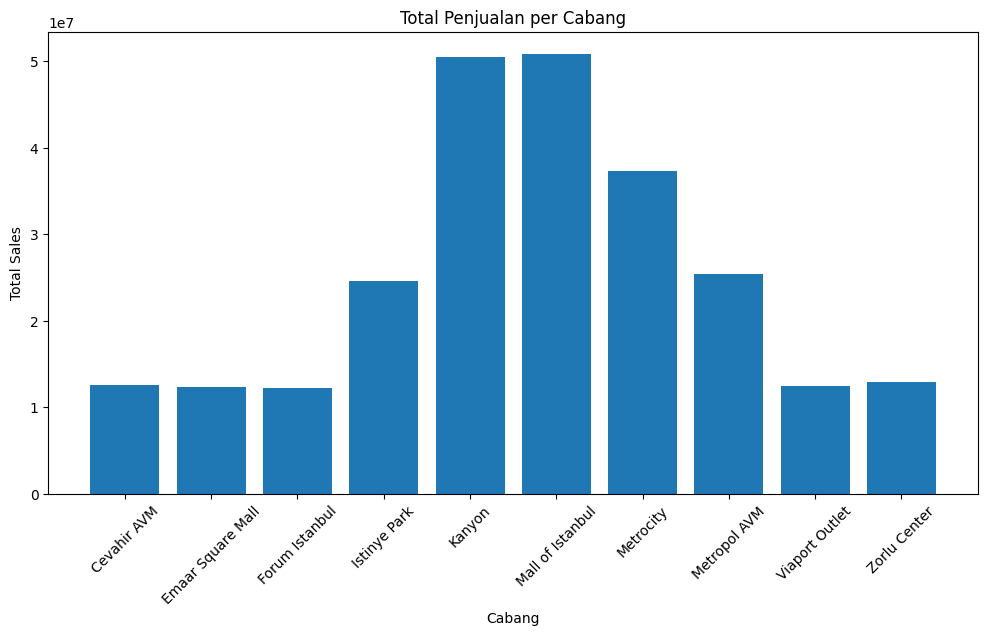

In [16]:
# Visualisasi 1 (Sebelum SAW) - Total Penjualan per Cabang
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.bar(
    saw_df['shopping_mall'],
    saw_df['total_sales']
)

plt.xticks(rotation=45)
plt.title('Total Penjualan per Cabang')
plt.xlabel('Cabang')
plt.ylabel('Total Sales')

plt.show()

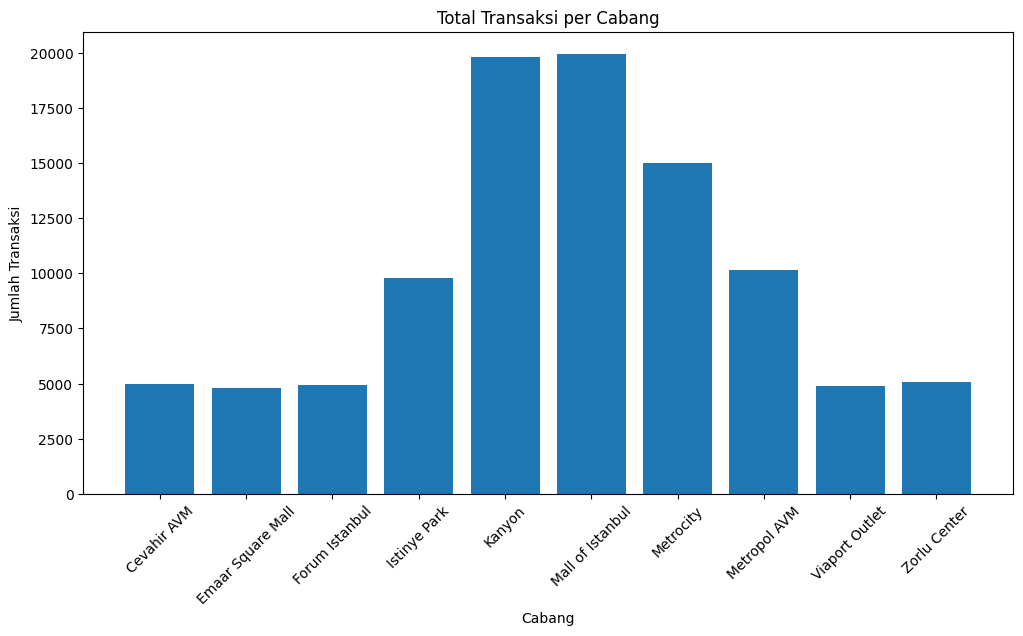

In [17]:
# Visualisasi 2 (Sebelum SAW)- Total Transaksi per Cabang
plt.figure(figsize=(12,6))

plt.bar(
    saw_df['shopping_mall'],
    saw_df['total_transaction']
)

plt.xticks(rotation=45)
plt.title('Total Transaksi per Cabang')
plt.xlabel('Cabang')
plt.ylabel('Jumlah Transaksi')

plt.show()

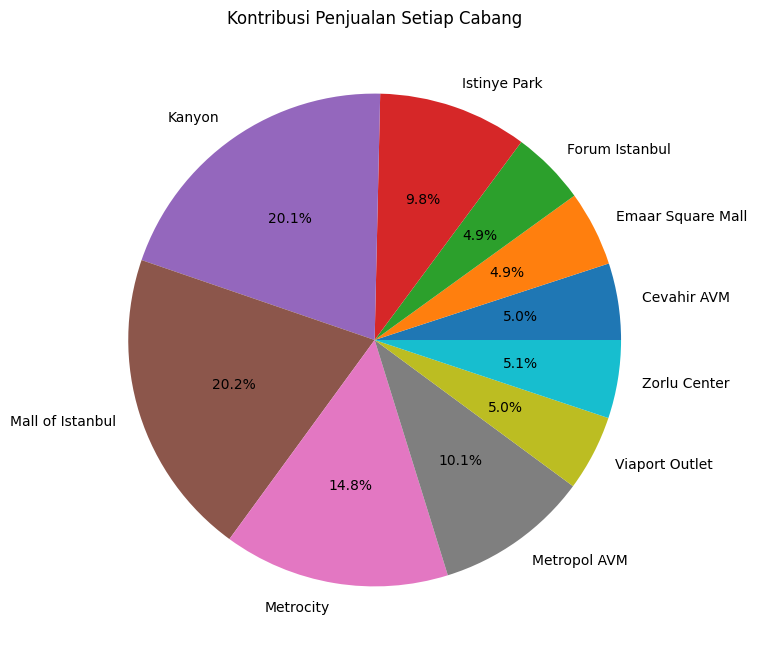

In [18]:
# Visualisasi 3 (Sebelum SAW)- Kontribusi Penjualan Cabang
plt.figure(figsize=(8,8))

plt.pie(
    saw_df['total_sales'],
    labels=saw_df['shopping_mall'],
    autopct='%1.1f%%'
)

plt.title('Kontribusi Penjualan Setiap Cabang')

plt.show()

# **6. Normalisasi Nilai Setiap Kriteria**  
Karena seluruh kriteria bertipe benefit, maka rumus normalisasi:  
Rij = Xij / max(Xij)

In [19]:
# Membuat Maatriks Keputusan
X = saw_df[[
    'total_sales',
    'total_transaction',
    'total_quantity',
    'average_sales'
]]

X

,total_sales,total_transaction,total_quantity,average_sales
0,12645138.20,4991,14949,2533.588099
1,12406100.29,4811,14501,2578.694718
2,12303921.24,4947,14852,2487.148017
3,24618827.68,9781,29465,2517.005181
4,50554231.10,19823,59457,2550.281547
5,50872481.68,19943,60114,2550.894132
6,37302787.33,15011,44894,2485.030133
7,25379913.19,10161,30530,2497.777108
8,12521339.72,4914,14716,2548.095181
9,12901053.82,5075,15234,2542.079570


In [20]:
# Normalisasi
R = X.copy()

for column in R.columns:
    R[column] = R[column] / R[column].max()

R

,total_sales,total_transaction,total_quantity,average_sales
0,0.248565,0.250263,0.248678,0.982508
1,0.243867,0.241238,0.241225,1.000000
2,0.241858,0.248057,0.247064,0.964499
3,0.483932,0.490448,0.490152,0.976077
4,0.993744,0.993983,0.989071,0.988982
5,1.000000,1.000000,1.000000,0.989219
6,0.733261,0.752695,0.746814,0.963678
7,0.498893,0.509502,0.507868,0.968621
8,0.246132,0.246402,0.244802,0.988134
9,0.253596,0.254475,0.253419,0.985801


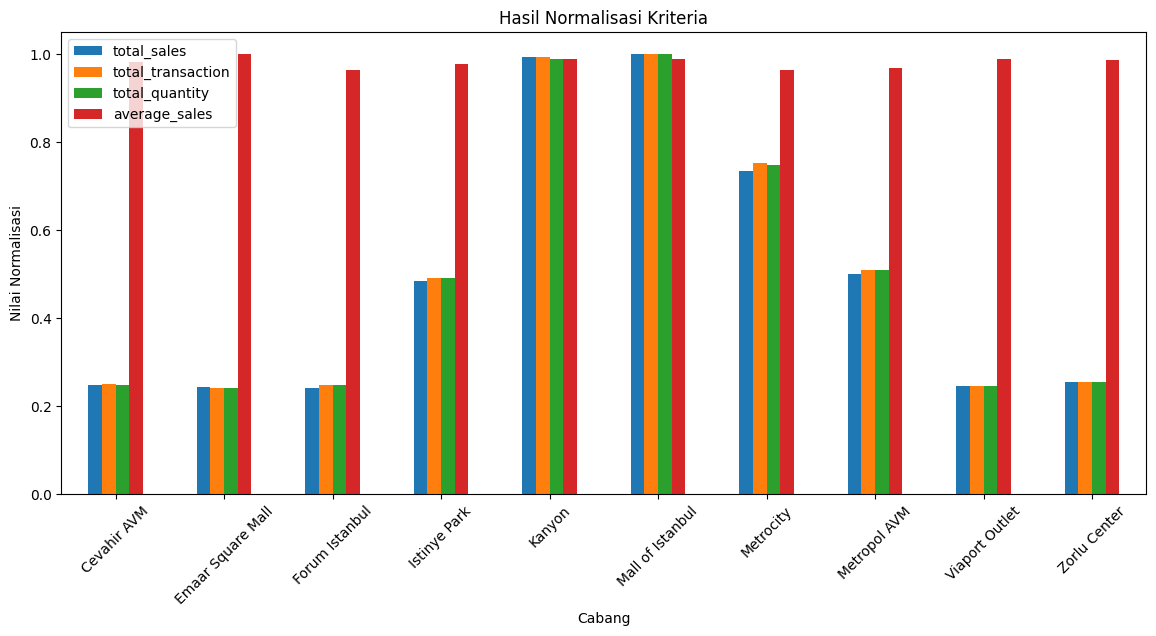

In [21]:
# Visualisasi Hasil Normalisasi
R.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title('Hasil Normalisasi Kriteria')
plt.xlabel('Cabang')
plt.ylabel('Nilai Normalisasi')

plt.xticks(
    ticks=range(len(saw_df)),
    labels=saw_df['shopping_mall'],
    rotation=45
)

plt.show()

# **7. Menentukan Bobot Setiap Kriteria**  
Bobot yang digunakan:

1.   Total Sales (0.4) - Menjadi prioritas utama
2.   Total Transaction (0.3) - Menjadi faktor kedua
3. Total Quantity (0.2) - Mendukunh performa penjualan.
4. Average Sales (0.1) - Sebagai indikator tambahan



In [24]:
# Menentukan bobot
weights = np.array([0.4, 0.3, 0.2, 0.1])

weights

array([0.4, 0.3, 0.2, 0.1])

# **8. Menghitung Nilai Alternatif**   
Menggunakan rumus SAW

In [25]:
# Menghitung nilai SAW
R['score'] = R.dot(weights)

R

,total_sales,total_transaction,total_quantity,average_sales,score
0,0.248565,0.250263,0.248678,0.982508,0.322491
1,0.243867,0.241238,0.241225,1.000000,0.318163
2,0.241858,0.248057,0.247064,0.964499,0.317023
3,0.483932,0.490448,0.490152,0.976077,0.536345
4,0.993744,0.993983,0.989071,0.988982,0.992405
5,1.000000,1.000000,1.000000,0.989219,0.998922
6,0.733261,0.752695,0.746814,0.963678,0.764843
7,0.498893,0.509502,0.507868,0.968621,0.550843
8,0.246132,0.246402,0.244802,0.988134,0.320147
9,0.253596,0.254475,0.253419,0.985801,0.327045


In [26]:
# Menambah nama cabang
R['shopping_mall'] = saw_df['shopping_mall']

R

,total_sales,total_transaction,total_quantity,average_sales,score,shopping_mall
0,0.248565,0.250263,0.248678,0.982508,0.322491,Cevahir AVM
1,0.243867,0.241238,0.241225,1.000000,0.318163,Emaar Square Mall
2,0.241858,0.248057,0.247064,0.964499,0.317023,Forum Istanbul
3,0.483932,0.490448,0.490152,0.976077,0.536345,Istinye Park
4,0.993744,0.993983,0.989071,0.988982,0.992405,Kanyon
5,1.000000,1.000000,1.000000,0.989219,0.998922,Mall of Istanbul
6,0.733261,0.752695,0.746814,0.963678,0.764843,Metrocity
7,0.498893,0.509502,0.507868,0.968621,0.550843,Metropol AVM
8,0.246132,0.246402,0.244802,0.988134,0.320147,Viaport Outlet
9,0.253596,0.254475,0.253419,0.985801,0.327045,Zorlu Center


In [27]:
# Ranking cabang
ranking = R[['shopping_mall', 'score']]\
    .sort_values(by='score', ascending=False)

ranking

,shopping_mall,score
5,Mall of Istanbul,0.998922
4,Kanyon,0.992405
6,Metrocity,0.764843
7,Metropol AVM,0.550843
3,Istinye Park,0.536345
9,Zorlu Center,0.327045
0,Cevahir AVM,0.322491
8,Viaport Outlet,0.320147
1,Emaar Square Mall,0.318163
2,Forum Istanbul,0.317023


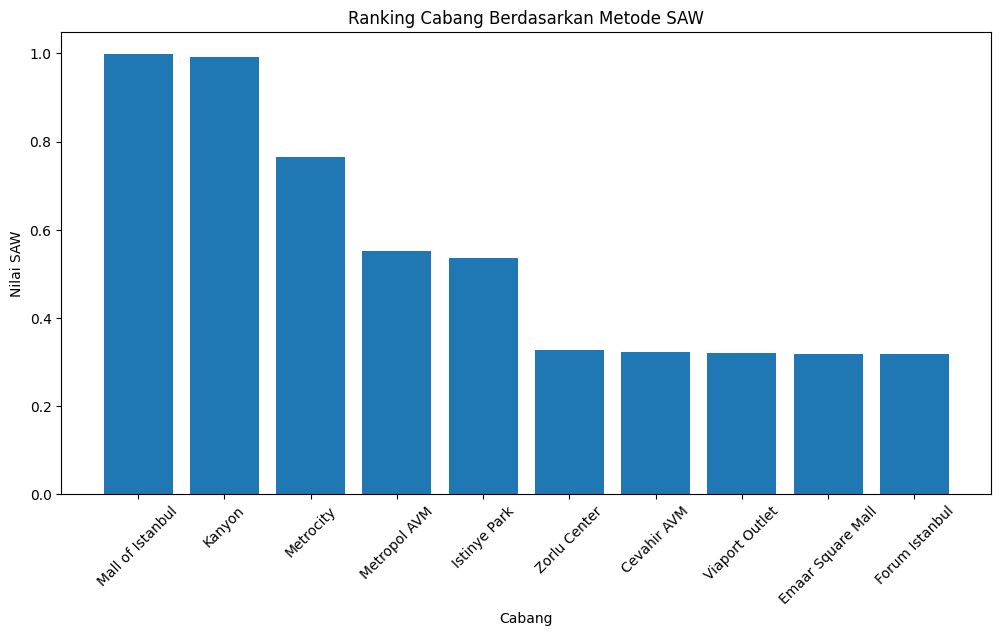

In [28]:
# Visualisasi Ranking SAW
plt.figure(figsize=(12,6))

plt.bar(
    ranking['shopping_mall'],
    ranking['score']
)

plt.xticks(rotation=45)

plt.title('Ranking Cabang Berdasarkan Metode SAW')
plt.xlabel('Cabang')
plt.ylabel('Nilai SAW')

plt.show()

# **9. Uji Sensitivitas**  
Hal ini dipakai untuk mengetahui apakah hasil ranking akan berubah jika bobot kriterianya diubah, karena SAW:


> Bobot sangat memengaruhi hasil akhir

Jik atadi kriteria yang diterapkan adalah:
1.   Total Sales (0.4) - Menjadi prioritas utama
2.   Total Transaction (0.3) - Menjadi faktor kedua
3. Total Quantity (0.2) - Mendukunh performa penjualan.
4. Average Sales (0.1) - Sebagai indikator tambahan

Maka kita ubah menjadi sebagai berikut:
1. Total Sales (0.5)
2. Total Transaction (0.2)
3. Total Quantity (0.2)
4. Average Sales (0.1)

In [29]:
# Bobot baru
new_weights = np.array([0.5, 0.2, 0.2, 0.1])

new_weights

array([0.5, 0.2, 0.2, 0.1])

In [31]:
# Hitung ulang SAW

R['new_score'] = (
    R['total_sales'] * new_weights[0] +
    R['total_transaction'] * new_weights[1] +
    R['total_quantity'] * new_weights[2] +
    R['average_sales'] * new_weights[3]
)

R

,total_sales,total_transaction,total_quantity,average_sales,score,shopping_mall,new_score
0,0.248565,0.250263,0.248678,0.982508,0.322491,Cevahir AVM,0.322322
1,0.243867,0.241238,0.241225,1.000000,0.318163,Emaar Square Mall,0.318426
2,0.241858,0.248057,0.247064,0.964499,0.317023,Forum Istanbul,0.316403
3,0.483932,0.490448,0.490152,0.976077,0.536345,Istinye Park,0.535694
4,0.993744,0.993983,0.989071,0.988982,0.992405,Kanyon,0.992381
5,1.000000,1.000000,1.000000,0.989219,0.998922,Mall of Istanbul,0.998922
6,0.733261,0.752695,0.746814,0.963678,0.764843,Metrocity,0.762900
7,0.498893,0.509502,0.507868,0.968621,0.550843,Metropol AVM,0.549783
8,0.246132,0.246402,0.244802,0.988134,0.320147,Viaport Outlet,0.320120
9,0.253596,0.254475,0.253419,0.985801,0.327045,Zorlu Center,0.326957


In [32]:
# Ranking baru
ranking_baru = R[['shopping_mall', 'new_score']]\
    .sort_values(by='new_score', ascending=False)

ranking_baru

,shopping_mall,new_score
5,Mall of Istanbul,0.998922
4,Kanyon,0.992381
6,Metrocity,0.762900
7,Metropol AVM,0.549783
3,Istinye Park,0.535694
9,Zorlu Center,0.326957
0,Cevahir AVM,0.322322
8,Viaport Outlet,0.320120
1,Emaar Square Mall,0.318426
2,Forum Istanbul,0.316403


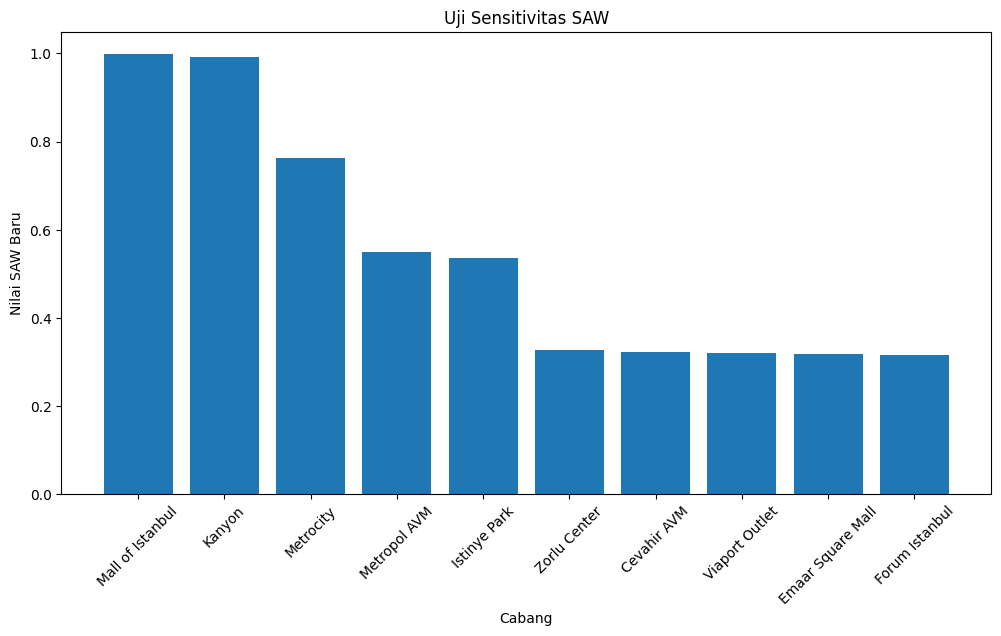

In [33]:
# Visualisasi Uji Sesnsitivitas
plt.figure(figsize=(12,6))

plt.bar(
    ranking_baru['shopping_mall'],
    ranking_baru['new_score']
)

plt.xticks(rotation=45)

plt.title('Uji Sensitivitas SAW')
plt.xlabel('Cabang')
plt.ylabel('Nilai SAW Baru')

plt.show()